## Making Plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [2]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import gala
import astropy.units as u
from astropy.table import Table

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import animation
from matplotlib.animation import FuncAnimation

import scipy
from scipy import stats
from scipy.interpolate import InterpolatedUnivariateSpline, UnivariateSpline
from scipy.optimize import curve_fit

import sys, importlib
sys.path.append('../code/')
import os
from df_helpers import *
from load_data_B2 import setup_B2
from load_data import load_data_actions
from helper import animate_m1m2

In [52]:
# %matplotlib inline
# plt.rcParams['xtick.direction'] = 'in'
# plt.rcParams['ytick.direction'] = 'in'
# plt.rcParams['xtick.top'] = True
# plt.rcParams['ytick.right'] = True
# plt.rcParams['xtick.major.size'] = 5
# plt.rcParams['ytick.major.size'] = 5
# plt.rcParams['xtick.major.width'] = 2
# plt.rcParams['ytick.major.width'] = 2
# plt.rcParams['xtick.minor.size'] = 4
# plt.rcParams['ytick.minor.size'] = 4
# plt.rcParams['xtick.minor.width'] = 1.0
# plt.rcParams['ytick.minor.width'] = 1.0
# plt.rcParams['axes.linewidth']=2

# plt.rcParams.update({
#     "lines.color": "white",
#     "patch.edgecolor": "white",
#     "text.color": "black",
#     "axes.facecolor": "white",
#     "axes.edgecolor": "lightgray",
#     "axes.labelcolor": "black",
#     "xtick.color": "black",
#     "ytick.color": "black",
#     "grid.color": "lightgray",
#     "figure.facecolor": "white",
#     "figure.edgecolor": "white",
#     "savefig.facecolor": "white",
#     "savefig.edgecolor": "white"})

### Satellite orbits

In [3]:
sgr_data_live = pd.read_csv('/mnt/ceph/users/jhunt/Bonsai/r2/B2/S1-orbit.txt', sep=' ', 
                       names=['x', 'y', 'z', 'Rxy', 'R', 'vx', 'vy', 'vz', 'A', 'B'], 
                       skiprows=0, nrows=600)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/ceph/users/jhunt/Bonsai/r2/B2/S1-orbit.txt'

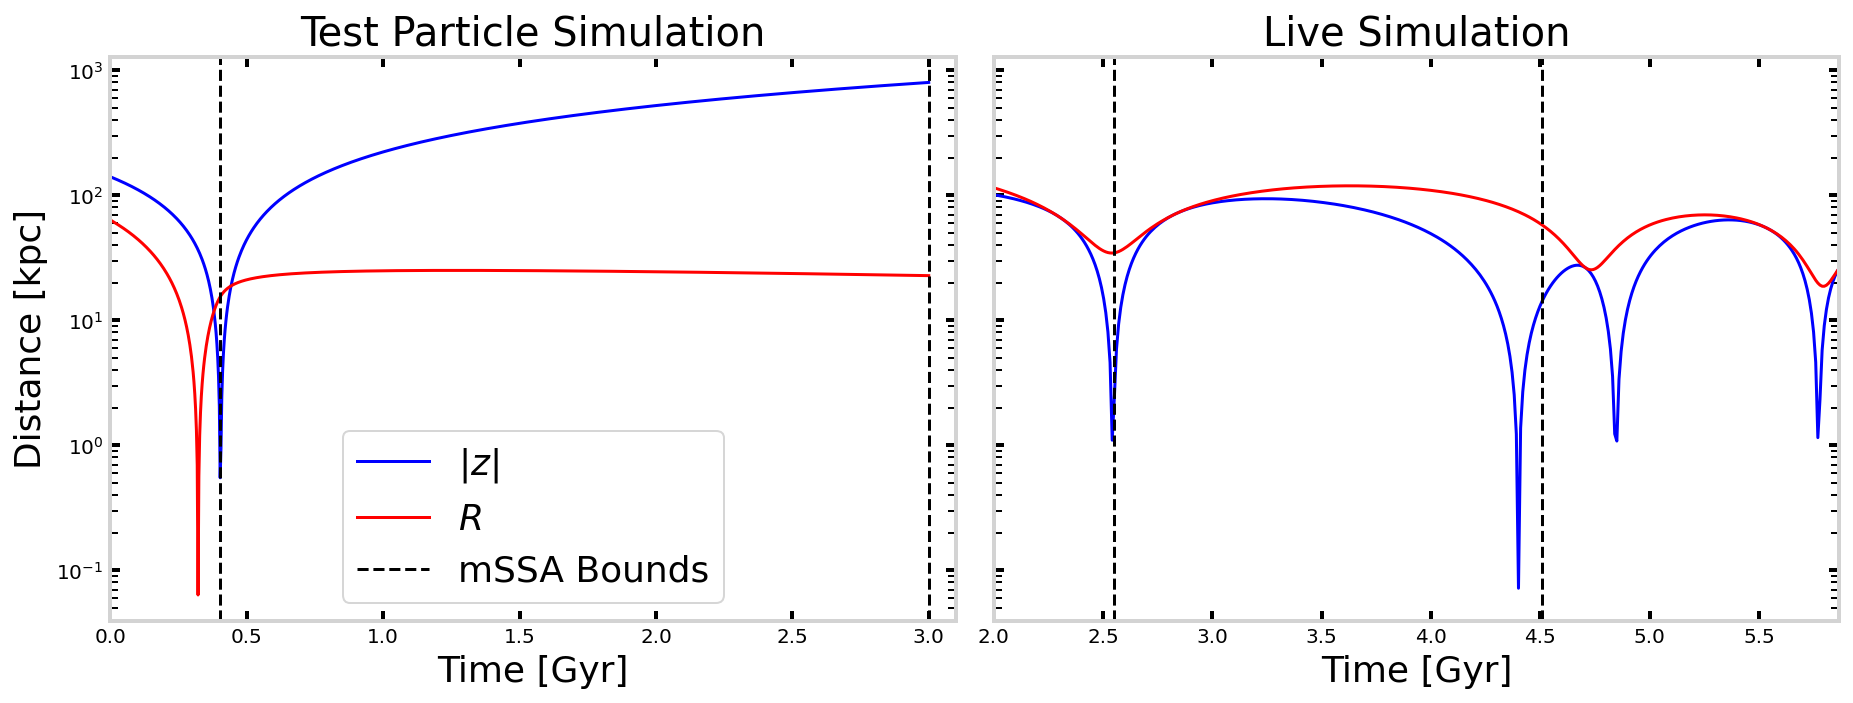

In [94]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(13,5), sharey=True)

ax1.plot(3+btime*bovy_conversion.time_in_Gyr(220.,8.),np.abs(sgrb.z(btime))*ro, c='b', label=r'$|z|$')
ax1.plot(3+btime*bovy_conversion.time_in_Gyr(220.,8.), sgrb.R(btime)*ro, c='r', label=r'$R$')
ax1.axvline(0.4, color='k', ls='dashed', label='mSSA Bounds')
ax1.axvline(3, color='k', ls='dashed')
ax1.set_xlabel('Time [Gyr]', fontsize=18)
ax1.set_title('Test Particle Simulation', fontsize=20)
ax1.set_xlim(0,3.1)
ax1.set_yscale('log')
ax1.set_ylabel('Distance [kpc]', fontsize=18)
ax1.legend(fontsize=18)

ax2.plot(sgr_data_live.index, np.abs(sgr_data_live.z), c='b')
ax2.plot(sgr_data_live.index, sgr_data_live.R, c='r')
ax2.axvline(sgr_data_live.index[260], color='k', ls='dashed')
ax2.axvline(sgr_data_live.index[460], color='k', ls='dashed')
ax2.set_xlabel('Time [Gyr]', fontsize=18)
ax2.set_title('Live Simulation', fontsize=20)
ax2.set_xlim(2,600*0.009778)


fig.tight_layout()
plt.savefig('/mnt/home/ktavangar/projects/MSSA_Snails/figures/sgr_orbits.pdf')
#plt.savefig('/mnt/home/ktavangar/projects/MSSA_Snails/figures/sgr_orbit.png')
plt.show()

### Test Particle BFE Reconstruction

In [ ]:
data10 = load_data_actions('../data/Kiyan_10.fits', '../data/Actions10.p')

Loading Data...


In [55]:
# What are the different regions

jphi_c = np.linspace(1000, 3500, 10+1)
tphi_c_ = np.linspace(0, 2*np.pi, 8+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)
print(jphi_c, tphi_c)

[1000. 1250. 1500. 1750. 2000. 2250. 2500. 2750. 3000. 3250. 3500.] [0.39269908 1.17809725 1.96349541 2.74889357 3.53429174 4.3196899
 5.10508806 5.89048623]


In [98]:
importlib.reload(sys.modules['helper'])
importlib.reload(sys.modules['df_helpers'])
from df_helpers import *

centers = np.array(np.meshgrid(jphi_c, tphi_c)).T.reshape(-1,2)
centers_xy = np.array([centers[:,0]*np.cos(centers[:,1]),
                       centers[:,0]*np.sin(centers[:,1])]).T.reshape(-1,2)
radius = [50, np.pi/16]

Jz_grid = (np.arange(0, 10, 0.1))**2
thetaz_grid = np.arange(0, 2*np.pi, np.pi/48)
m_max, n_max, n_maxs = 3, 20, [1,20, 20]

center = [1500, np.pi] # action, angle ([2000, 3.7] is our basic one)
radius = [50, np.pi/16] #kpc (square radius) ([50, 0.05 is our basic one])
LS = LaguerreSnails(data90, center, radius, Jz_grid, thetaz_grid, m_max, n_max, 10)

In [99]:
LS.get_coeffs()
LS.make_spiral_residual()
LS.make_spiral_recon(n_maxs)

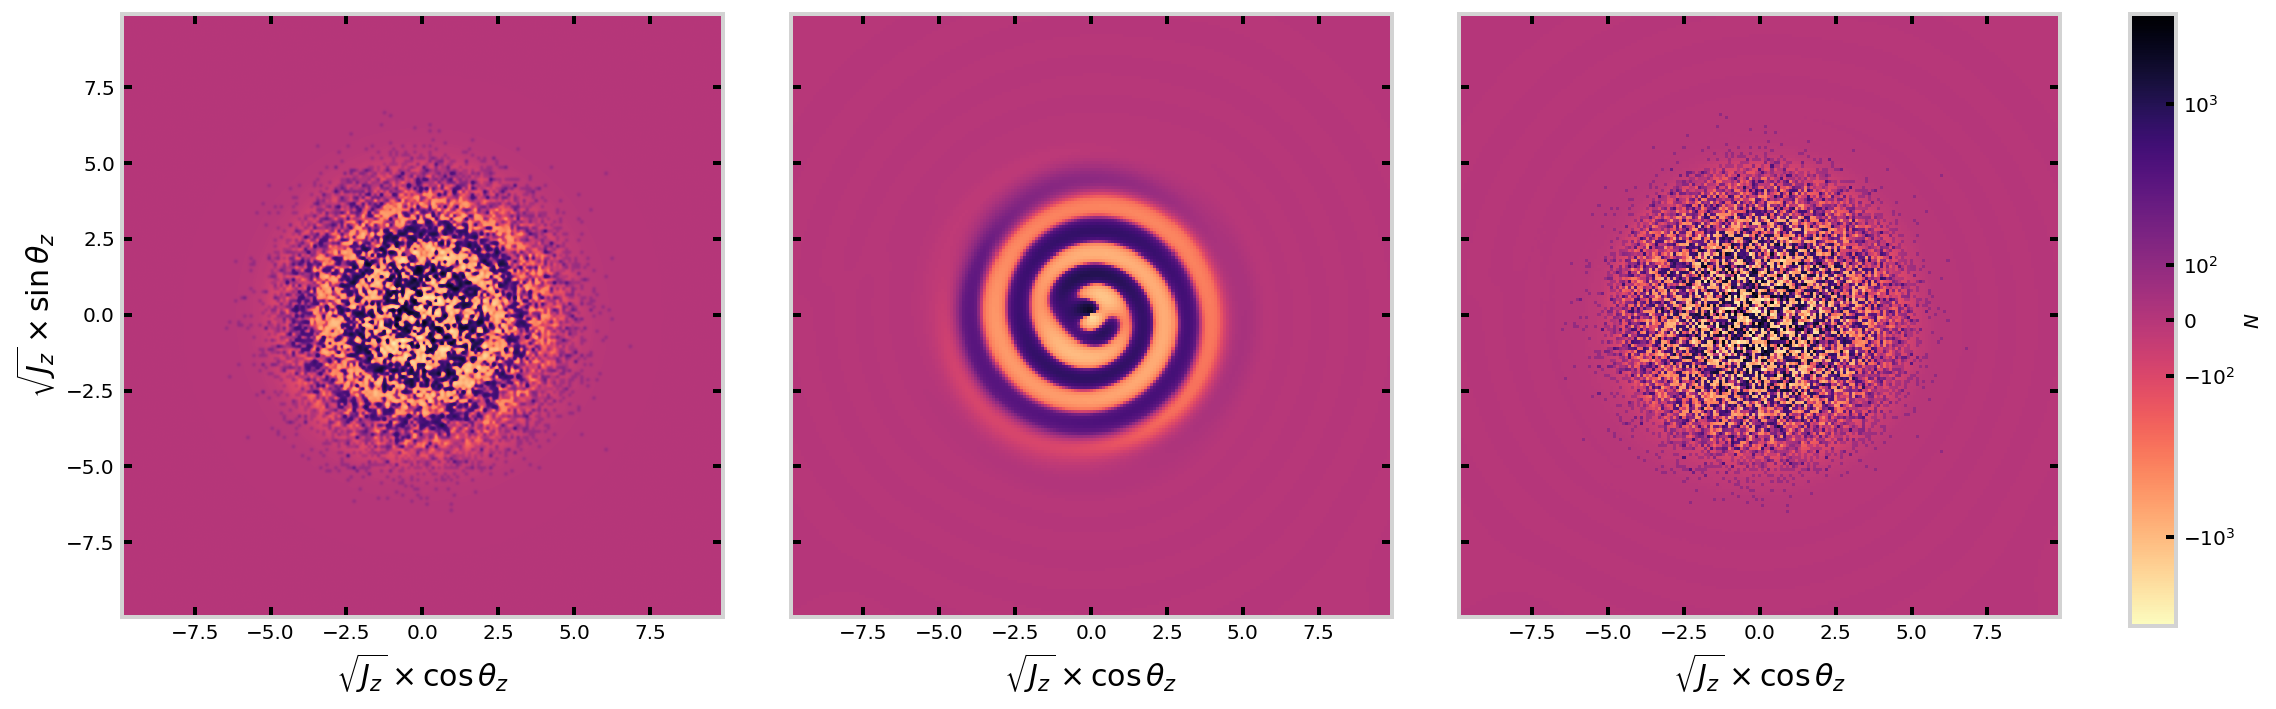

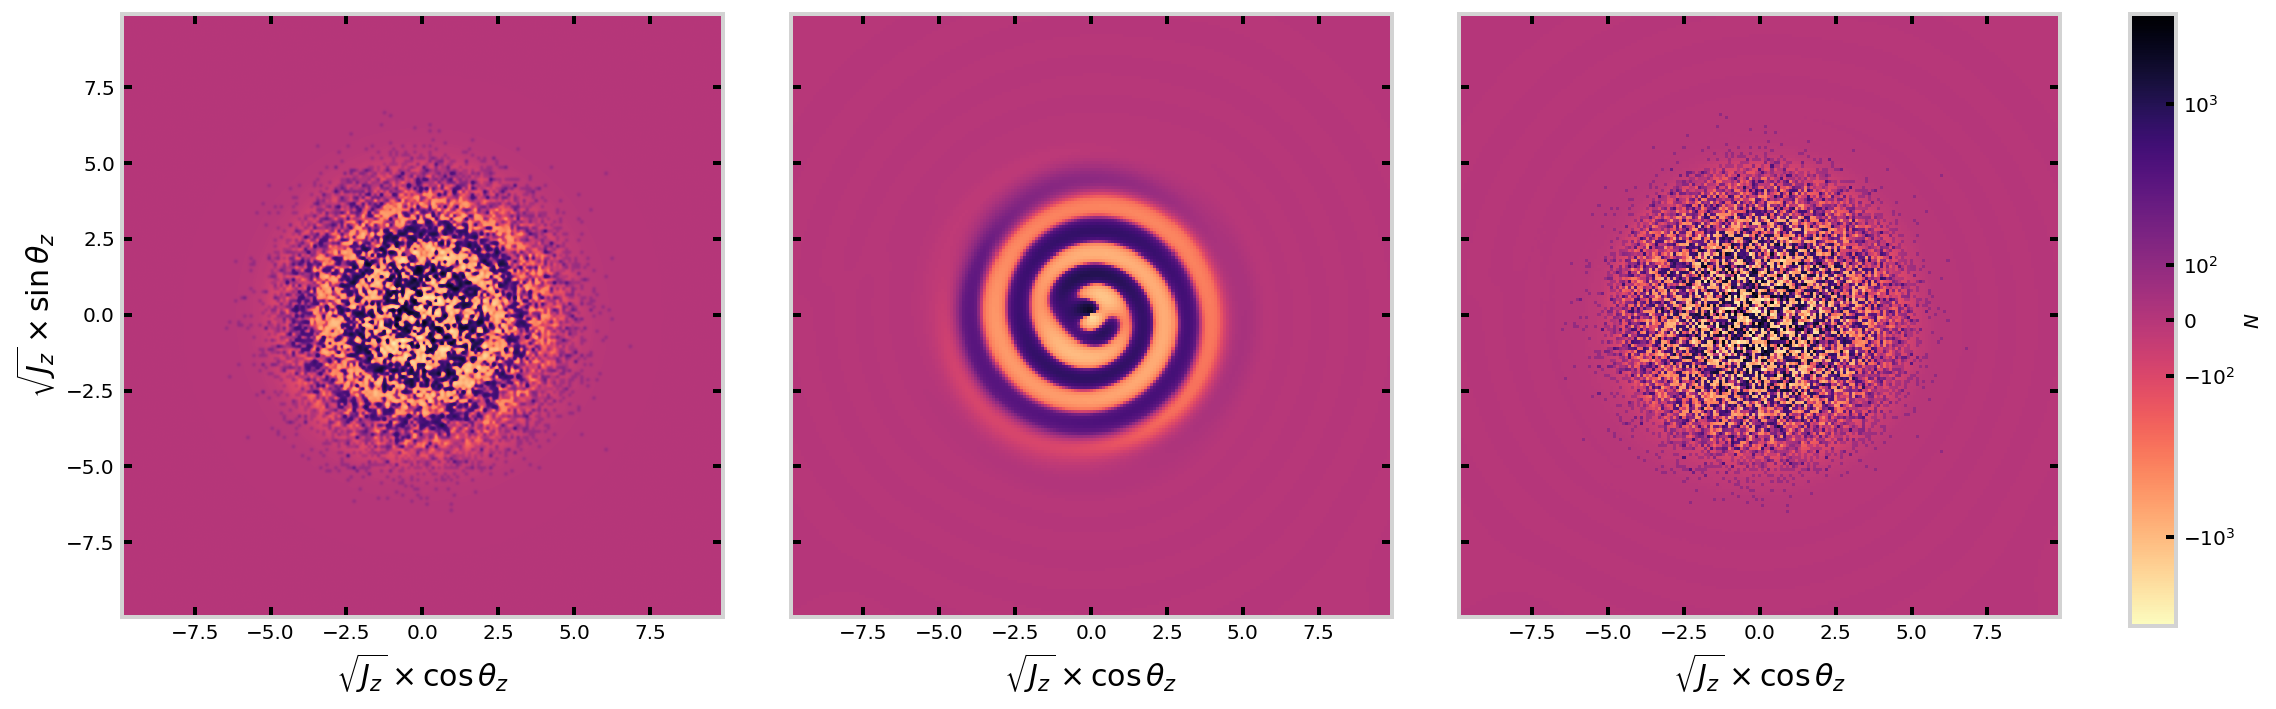

In [100]:
LS.summary_plots()

In [ ]:
LS.get_pitch_phase_angles(m=1)